In [1]:
import pandas as pd, si_units as si, ternary, matplotlib.pyplot as plt, numpy as np, feos, sys, json
import TERNARY_CLASS as TC
sys.path.append("..")
import PLOT_SETTINGS as ps
from molmass import Formula

In [2]:
parameters      = feos.Parameters.from_json(["carbon dioxide", "hydrogen", "argon"], "../parameters.json")
T_vals          = np.arange(200,301,10)           
n_total         = 1.0 * si.MOL
CO2_comp        = 0.95
feeds           = TC.generate_feeds(CO2=0.95, n_points=4)
eos             = feos.HelmholtzEnergyFunctional.pcsaft(parameters)
TC.print_array2d(feeds)
parameters

  i |         z1 |         z2 |         z3
---------------------------------------------------------
  1 |       0.9500       0.0167       0.0333
  2 |       0.9500       0.0333       0.0167


|component|molarweight|m|sigma|epsilon_k|
|-|-|-|-|-|
|carbon dioxide|43.99|2.53096|2.57855|153.31864|
|hydrogen|2.016|1.0|3.002|51.343|
|argon|39.962|1.0|3.37751|117.80903|


Feed 1: z = [0.95       0.01666667 0.03333333]
Critical Point: T = 305.77 K, P = 90.42 bar
Bubble calculation failed at T = 297 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 298 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 304 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 305 K: Iteration resulted in trivial solution.
Dew calculation failed at T = 300 K: Iteration resulted in trivial solution.

Feed 2: z = [0.95       0.03333333 0.01666667]
Critical Point: T = 306.11 K, P = 93.54 bar
Bubble calculation failed at T = 301 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 302 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 303 K: Iteration resulted in trivial solution.
Bubble calculation failed at T = 306 K: Iteration resulted in trivial solution.
Dew calculation failed at T = 300 K: Iteration resulted in trivial solution.

feed_1:
  T = 200 K: 

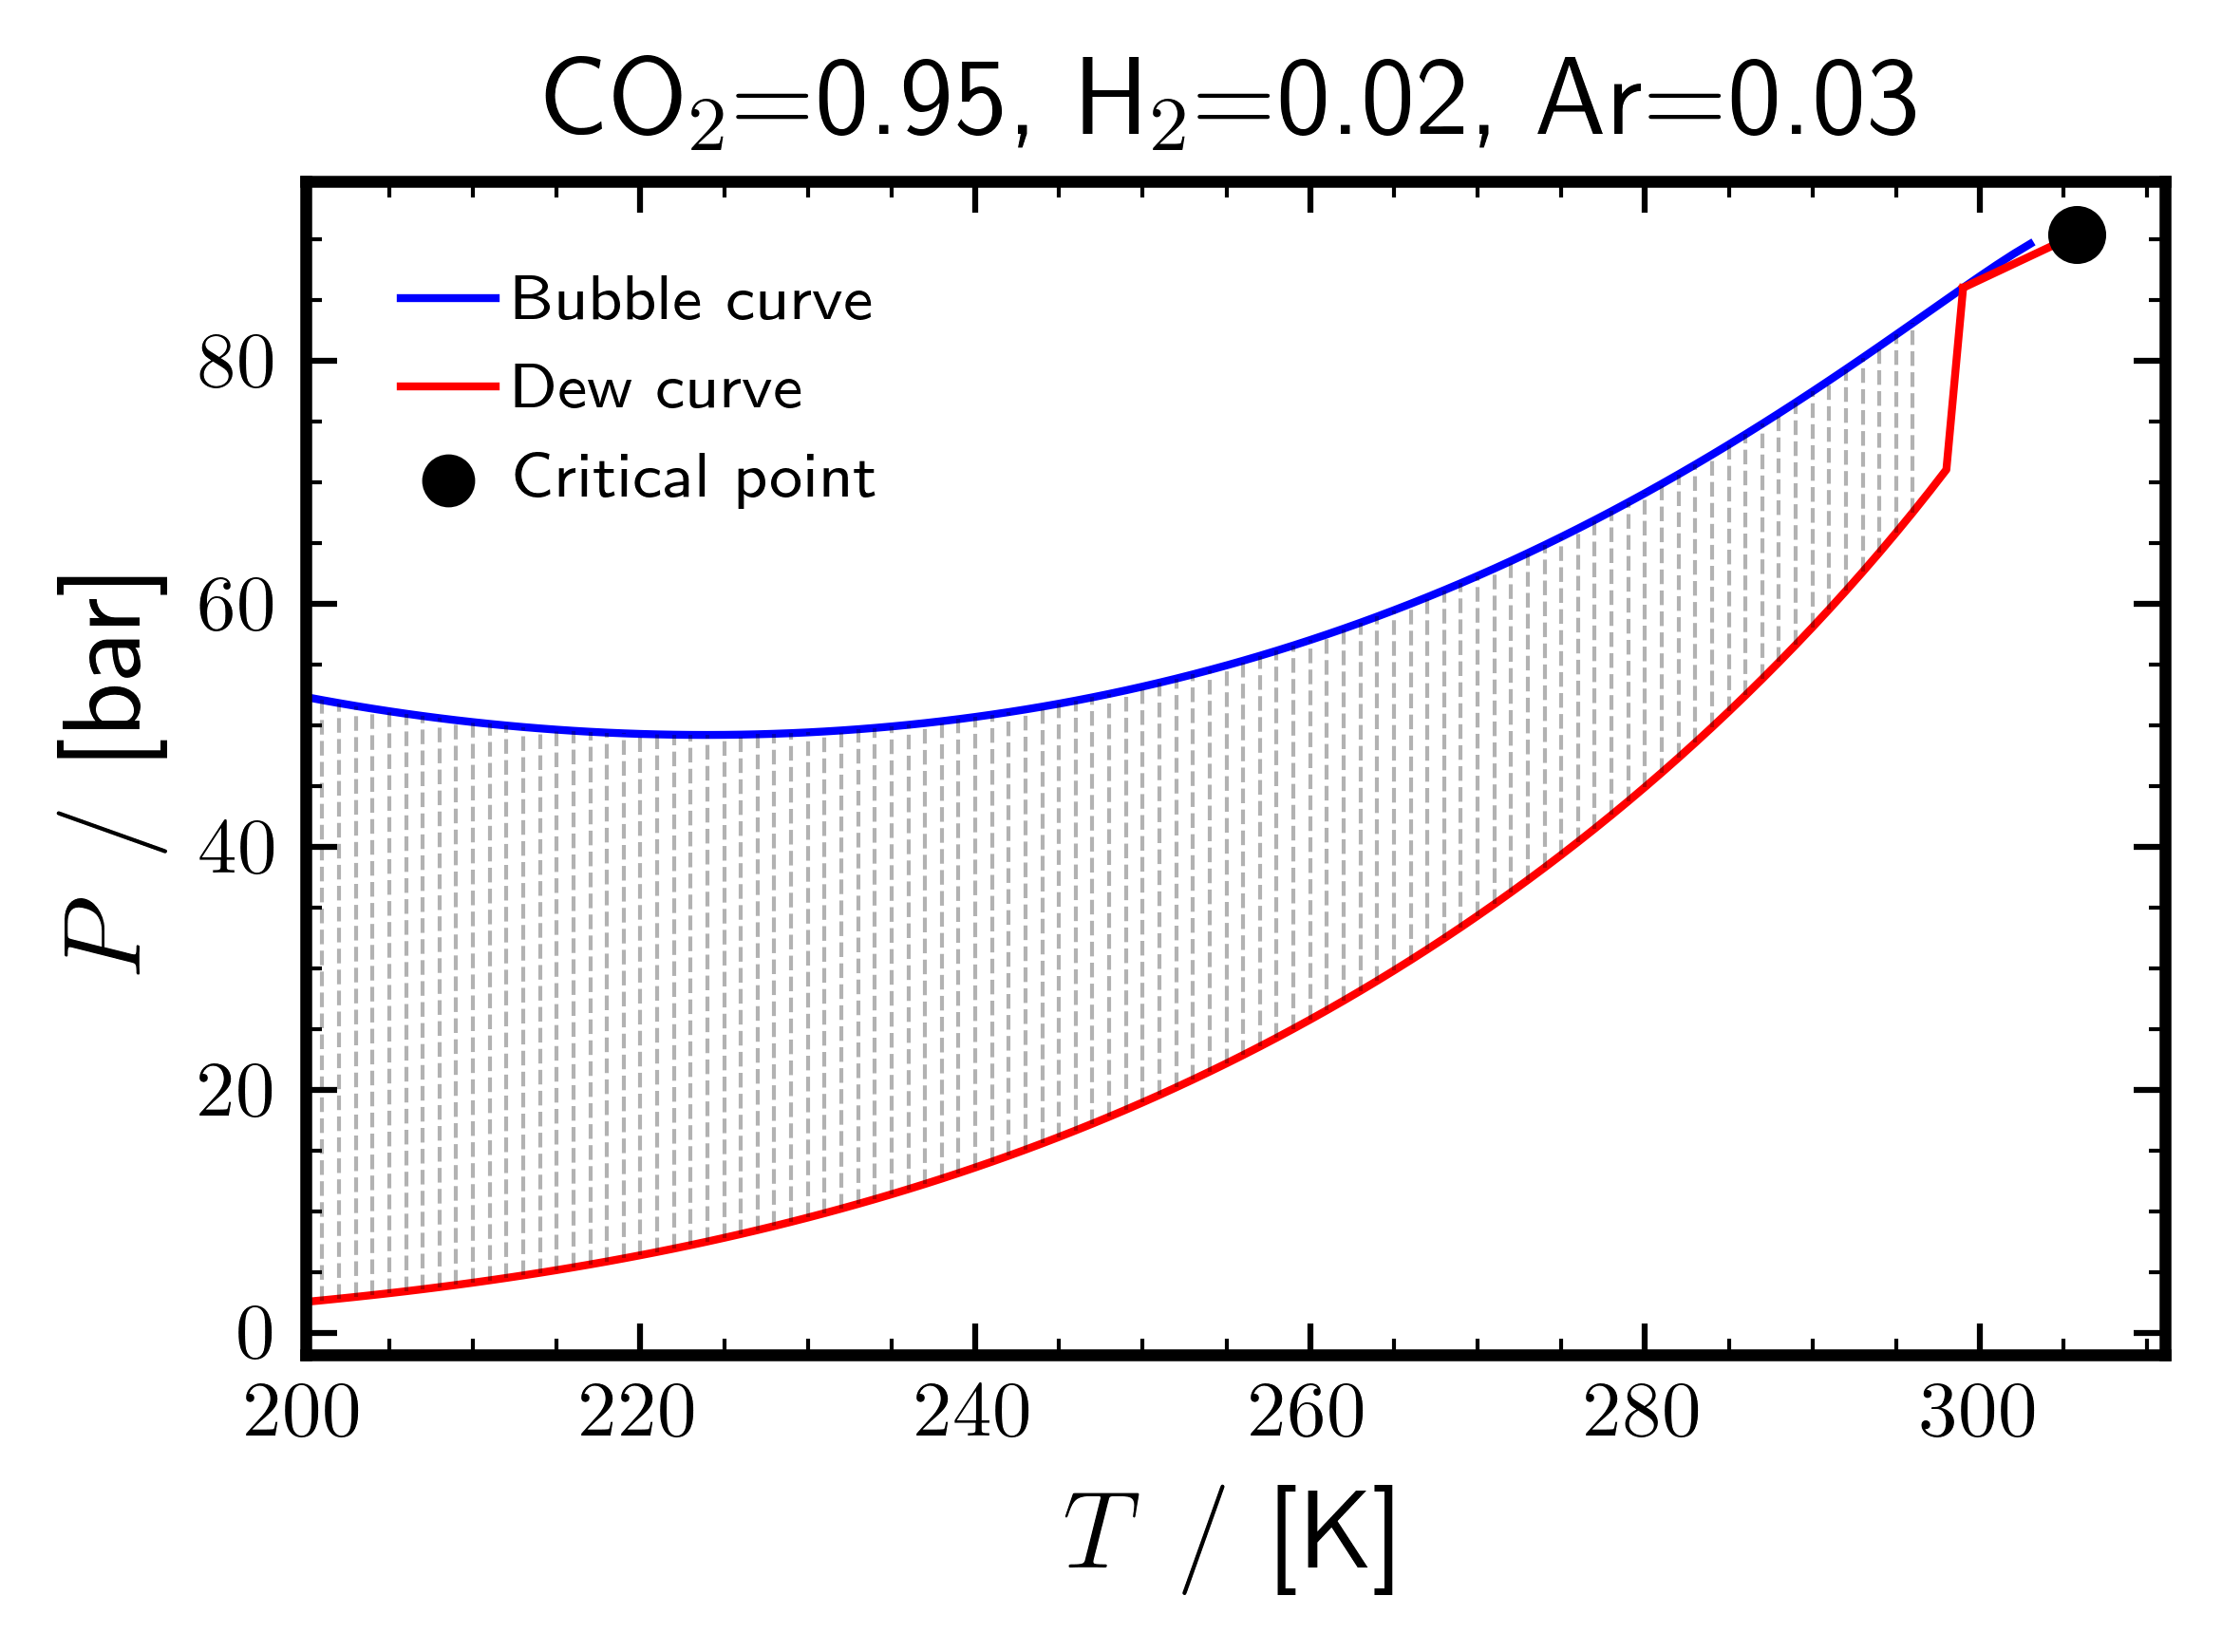

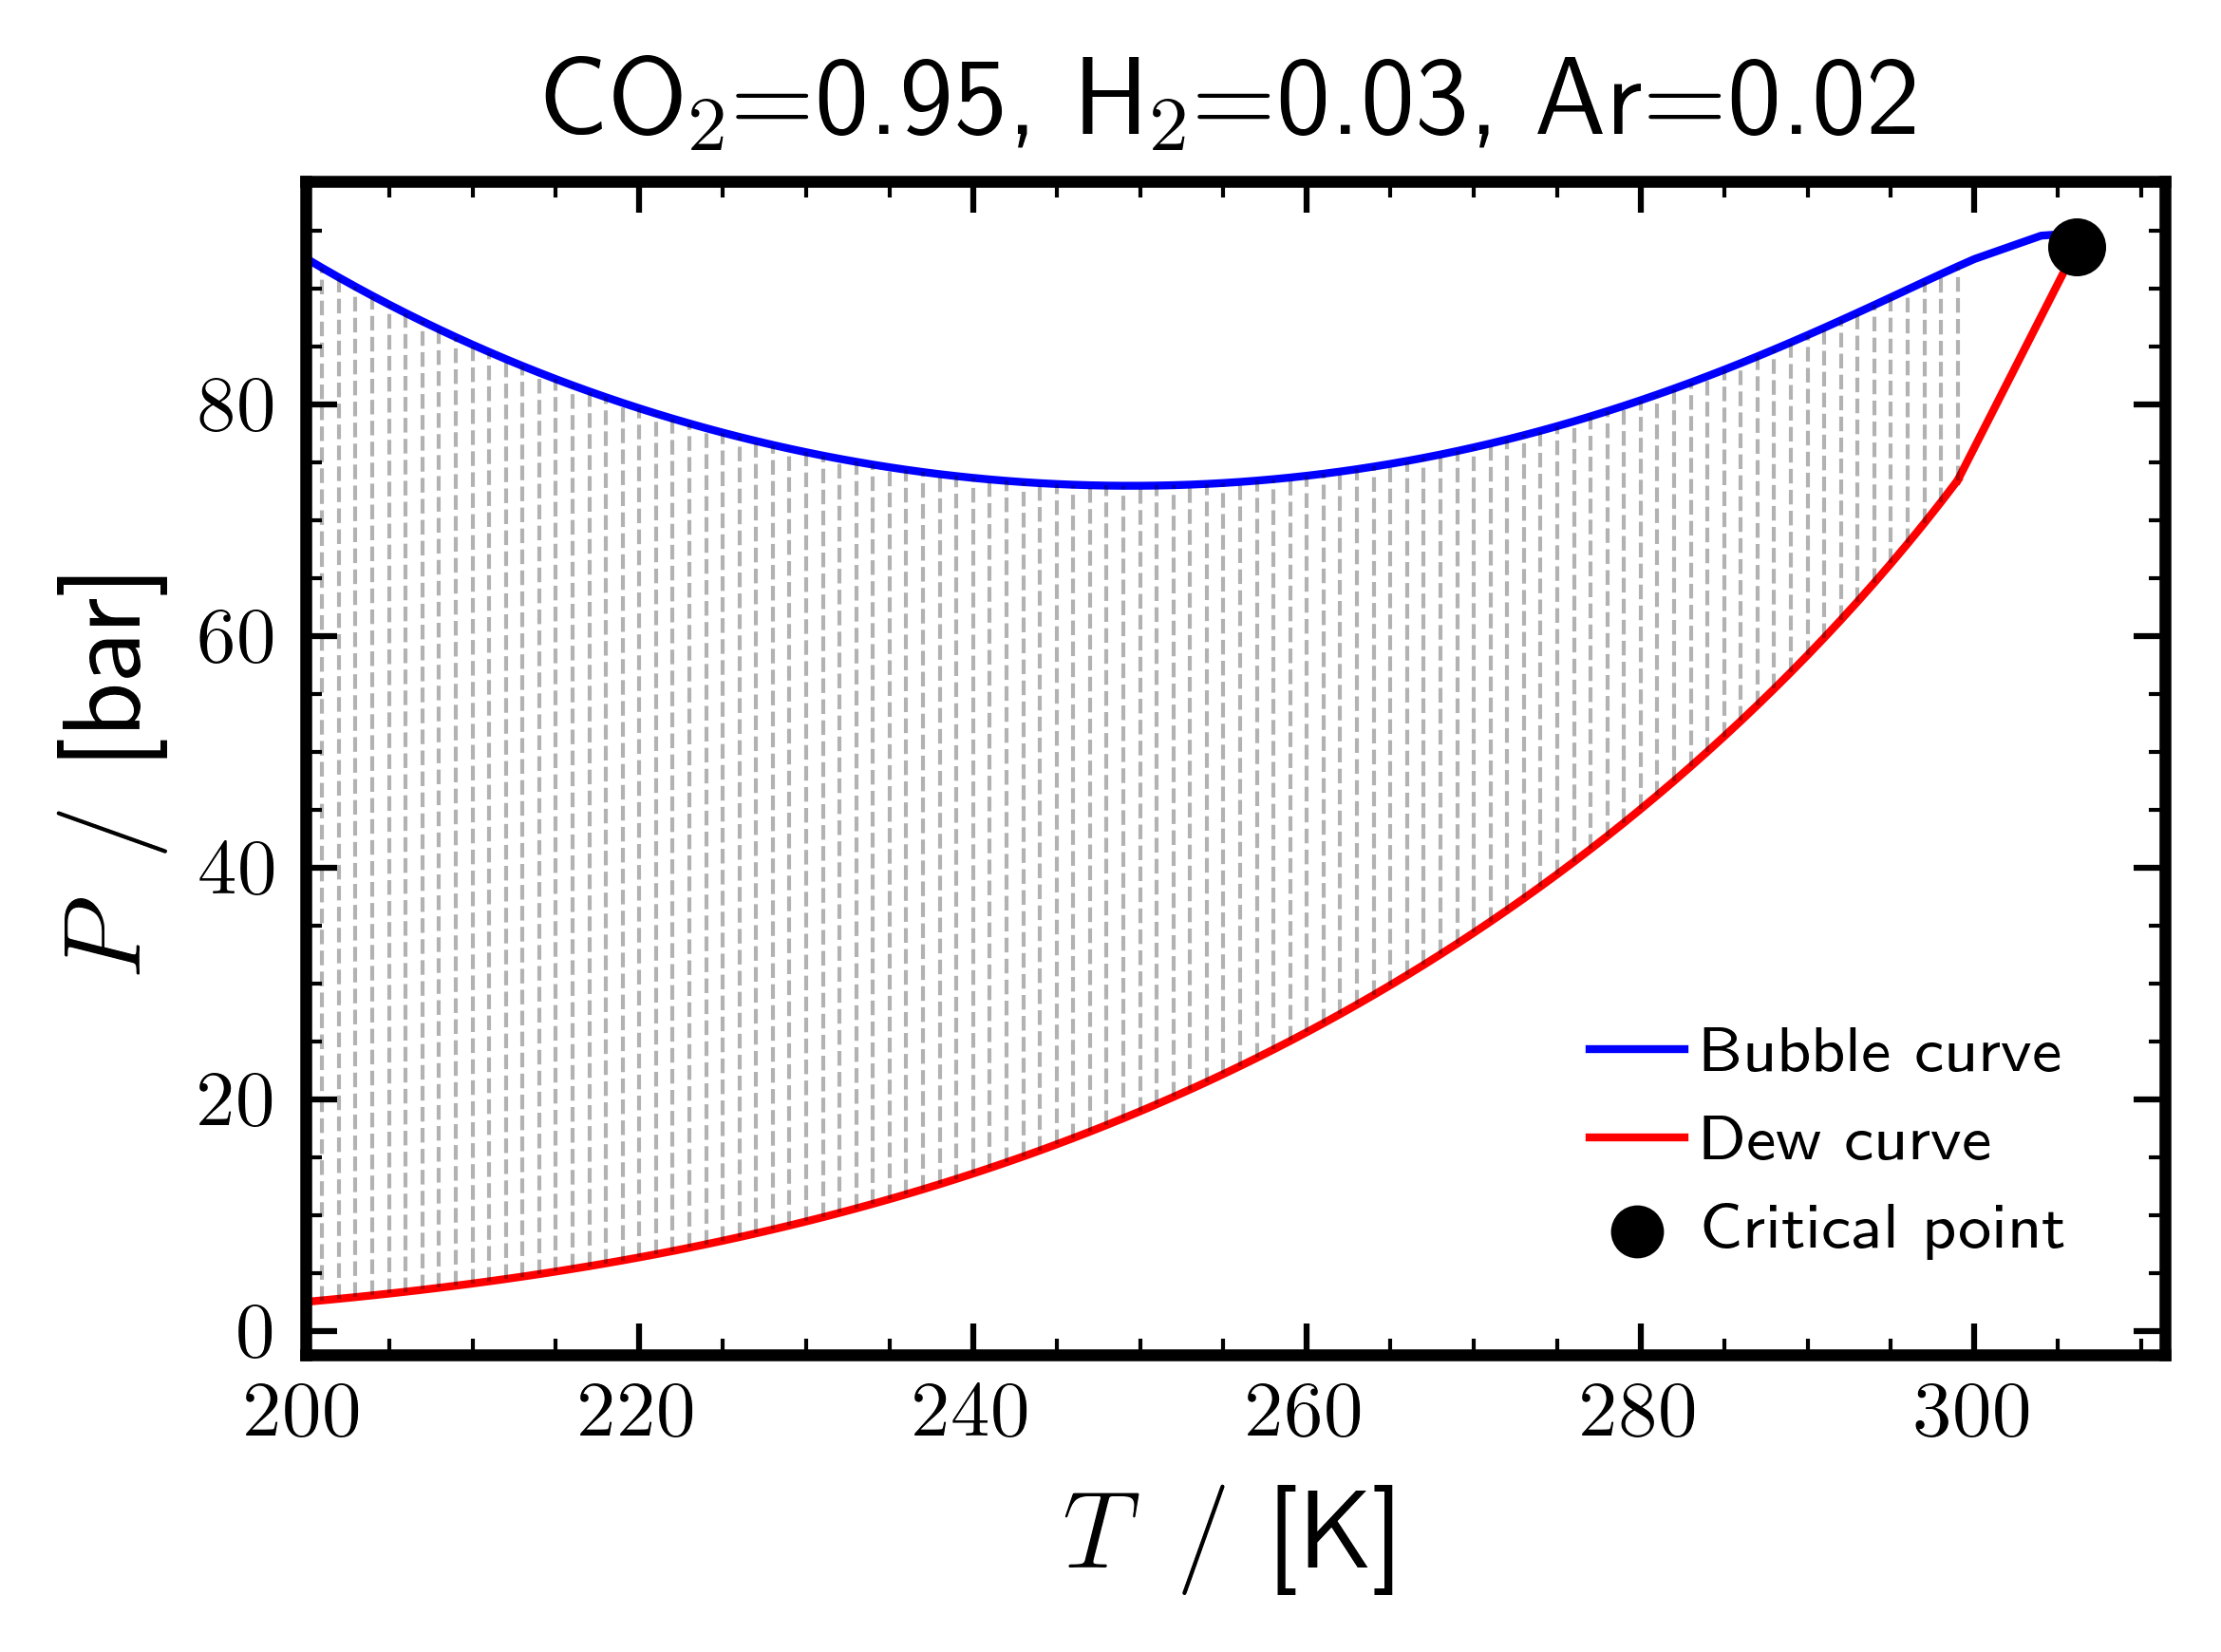

In [ ]:
components      = TC.components(parameters)
molar_masses    = [Formula(c).mass for c in components]  # g/mol

PT_results      = {}
verbose=True
P_TOL           = 0.01  # Pressure [bar] tolerance for flash calculations excempting at the saturation points

for k, z in enumerate(feeds, start=1):
    
    # --- normalize + mole amounts ---
    z = TC.normalize_z(z)
    feed = TC.compute_feed_moles(z, n_total)
    
    # print(feed)
    if verbose:
        print(f"\nFeed {k}: z = {z}") 
    
    # --- critical point at this composition ---
    CT, CP = TC.compute_CT(feos, eos, z, T_guess=T_vals[0])
    if verbose:
        print(f"Critical Point: T = {CT/si.KELVIN:.2f} K, P = {CP/si.BAR:.2f} bar")
    
    # ---- compute bubble and dew curves ----
    T_values = range(200, int(CT / si.KELVIN) + 1)
    T_bubble, bubble_pressures  = TC.compute_bubble_curve(eos, T_values, feed, verbose=verbose)
    T_dew, dew_pressures        = TC.compute_dew_curve(eos, T_values, feed, verbose=verbose)
    
    # ---- store in dictionary (JSON-safe: convert numpy types to Python floats) ----
    PT_results[f"feed_{k}"] = {
        "z": [round(float(x), 6) for x in np.asarray(z, dtype=float)],
        "TC_K": round(float(CT / si.KELVIN), 2),
        "PC_bar": round(float(CP / si.BAR), 2),
        "bubble": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bubble, bubble_pressures)],
        "dew":    [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew, dew_pressures)],
    }

# ---- write to file ----
out_file = "PT_Phase_Envelope.json"
with open(out_file, "w", encoding="utf-8") as f:
    json.dump(PT_results, f, indent=2)

isothermal_data = {}

for feed_key, feed in PT_results.items():

    TP_z = np.array(feed.get("z", []))
    
    fig, ax = TC.plot_PT(PT_results, feed_key, parameters)
    
    bub = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("bubble", [])}
    dew = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("dew", [])}
    
    common_T = sorted(set(bub) & set(dew))

    # ---- store ----
    isothermal_data[feed_key] = [
        {"T_K": T, "P_bubble_bar": bub[T], "P_dew_bar": dew[T]} for T in common_T]
    
    if verbose:
        print(f"\n{feed_key}:")
        for T in common_T:
            print(f"  T = {T} K: P_bubble = {bub[T]:.2f} bar, P_dew = {dew[T]:.2f} bar")
    
    if common_T:
        for T in common_T:
            P_b = bub[T]
            P_d = dew[T]

            if P_b >= P_d:
                
                pressures = np.linspace(P_d + P_TOL, P_b - P_TOL, 10)
                
                # ---- optional: PLOT ----
                ax.plot([T, T], [P_d, P_b], linewidth=0.5, linestyle="--", color="k", alpha =0.3)
                
                for P in pressures:
                    
                    if verbose:
                        print(f"T = {T} K | P_flash = {P:.2f} | z = {TP_z}")
                       
                    # --- TP flash ---
                    try:
                        eq, x, y, liquid_density, vapor_density = TC.tp_flash(feos, eos, T*si.KELVIN, P*si.BAR, TP_z*si.MOL, molar_masses)
                    except Exception as e:
                        print(f"TP flash failed for z = {TP_z} at T = {T} K, P = {P:.2f} bar: {e}")
                        continue
                    
                    # --- planar interface & surface tension ---
                    interface = TC.build_planar_interface(eq,critical_temperature=CT,n_grid=500,l_grid=100.0)
                    
                    try:
                        gamma_mN_m, interfacial_thickness_nm, (E_1, E_2, E_3) = TC.solve_interface_properties(interface, si)
                    except Exception as e:
                        print(f"Surface tension calculation failed for z = {TP_z} at T = {T} K, P = {P:.2f} bar: {e}")
                        gamma_mN_m = np.nan
                        interfacial_thickness_nm = np.nan
                        E_1, E_2, E_3 = np.nan, np.nan, np.nan
                    
                    if verbose:
                        print(f"T = {T} K | P_flash = {P:.2f} bar | gamma = {gamma_mN_m:.6f} mN/m")

                    # rows.append(TC.row_append(z, x, y, liquid_density, vapor_density, 
                    #     CT, gamma_mN_m, interfacial_thickness_nm, components,(E_1, E_2, E_3)))
                    

    ps.save_plot(fig, f"PT_{feed_key}")

In [ ]:
# TP_z = np.array([0.95, 0.01, 0.04])
# try:
#     eq, x, y, liquid_density, vapor_density = TC.tp_flash(feos, eos, 220*si.KELVIN, 20*si.BAR, TP_z*si.MOL, molar_masses)
# except Exception as e:
#     print(f"TP flash failed for z = {TP_z}: {e}")            

In [ ]:
rows = []

for k, z in enumerate(feeds, start=1):

    # --- normalize + mole amounts ---
    z = TC.normalize_z(z)
    feed = TC.compute_feed_moles(z, n_total)
    
    # --- TP flash ---
    try:
        eq, x, y, liquid_density, vapor_density = TC.tp_flash(feos, eos, T, P, feed, molar_masses)
    except Exception as e:
        print(f"TP flash failed for z = {z}: {e}")
        continue

    # --- planar interface & surface tension ---
    interface = TC.build_planar_interface(eq,critical_temperature=CT,n_grid=500,l_grid=100.0)
    
    try:
        gamma_mN_m, interfacial_thickness_nm, (E_1, E_2, E_3) = TC.solve_interface_properties(interface, si)
    except Exception as e:
        print(f"Surface tension calculation failed for z = {z}: {e}")
        gamma_mN_m = np.nan
        interfacial_thickness_nm = np.nan
        E_1, E_2, E_3 = np.nan, np.nan, np.nan

    rows.append(TC.row_append(z, x, y, liquid_density, vapor_density, 
        CT, gamma_mN_m, interfacial_thickness_nm, components,(E_1, E_2, E_3)))

    print(f"\nCase {k}")
    print("z =", z)
    print("Tc [K] =", float(CT/si.KELVIN))
    print(f"surface tension [mN/m] = {gamma_mN_m:.6f}")

In [ ]:
df = pd.DataFrame(rows)
df.to_csv("vle_interface_results.csv", index=False)
print(df)

In [ ]:
fig, tax = TC.plot_ternary_vle(rows,feeds,components,permutation="210")
TC.save_plot(fig, "ternary_CO2_H2_Ar")

In [ ]:
# IFT PLOT

fig1, ax1 = ps.plot_init()

ax1.plot(df["x_CO2"], df["gamma_mN_m"], marker=None, color="blue")

ax1.minorticks_on()
# ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
# ax1.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))
# ax1.yaxis.set_major_locator(ticker.MultipleLocator(1))
# ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax1.set_xlabel(r'$x_{\mathrm{Ar}} \; / \; [\mathrm{mol \; mol^{-1}}]$', fontsize=ps.label_fontsize)
ax1.set_ylabel(r'$\gamma \; / \; [\mathrm{mN\,m^{-1}}]$', fontsize=ps.label_fontsize)

plt.show()
ps.save_plot(fig1, f'IFT_TM')